In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
import copy
import torch.optim as optim
import math

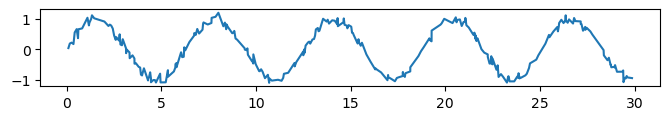

In [93]:
#--- 1. Generate Sine Wave Data
#take random ts
t = np.sort(np.random.choice(100000000, size =300, replace = False))/100000000*30
y = np.sin(t) + 0.10* np.random.normal(0,1,len(t))

#plot
plt.subplots(1, 1, figsize=(8, 1))
plt.plot(t, y)
plt.show()

In [94]:
# define window size 
window_size = 30


In [95]:
# ???? not convinced

# To stabilize training, I suggest normalizing t before feeding to the model:
#import math
#t = (t - t.min()) / (t.max() - t.min()) * 2 * math.pi  # scale into [0, 2π]
# that way, the sin–cos encoding works on a meaningful scale, and t_proj doesn’t blow up.

In [96]:
### prepare data for Transformer 
X_seq2 = []
y_seq2 = []

for i in range(len(y) - window_size):
    t_window = t[i:i+window_size]      # past time stamps
    y_window = y[i:i+window_size]      # past values
    y_next = y[i+window_size]          # target (the next step)

    seq_input = np.stack([y_window, t_window], axis=1)  # shape (window, 2)
    X_seq2.append(seq_input)
    y_seq2.append(y_next)

X_seq2 = np.array(X_seq2)   # (N, window_size, 2)
y_seq2 = np.array(y_seq2)

# Torch tensors
X_tensor2 = torch.tensor(X_seq2, dtype=torch.float32)
y_tensor2 = torch.tensor(y_seq2, dtype=torch.float32)

train_size = int(0.8 * len(X_tensor2))

train_X2, test_X2 = X_tensor2[:train_size], X_tensor2[train_size:]
train_y2, test_y2 = y_tensor2[:train_size], y_tensor2[train_size:]


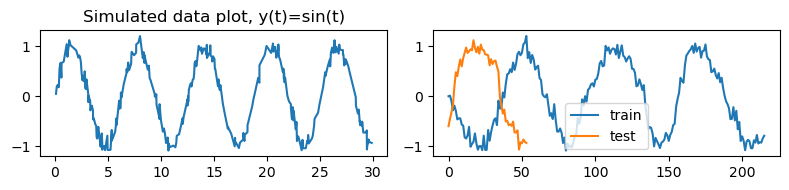

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(t,y); axs[0].set_title("Simulated data plot, y(t)=sin(t)"); 
axs[1].plot(train_y2, label = "train"); axs[1].plot(test_y2, label = "test"); axs[1].legend()
plt.tight_layout()
plt.show()

In [98]:
# M1. Simple MLP Model
class MLPWithTime(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        input_dim = 2 * window_size + 1
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1)

##  Transformer to explicitly model the dependency between `t` (time) and `y` (signal), 

so that if the relationship is sinusoidal (`y ≈ sin(t)`), the model can *discover* that structure and then generate accurate `y` values for new `t`.

### Key Design Principles

1. **Treat `t` as more than just a sequence index**
   Normally, Transformers assume sequence position is implicit (0, 1, 2, …).
   In your case, `t` is a real-valued continuous variable, and the main driver of `y`.

2. **Embed `t` properly**
   Instead of raw scalar `t`, you should expand it into a rich embedding.

   * Sin–cos encoding = strong prior for periodic signals.
   * Linear projection of raw `t` = lets the model learn arbitrary mappings.
   * Combining both = best of both worlds.

3. **Model Input**
   Each token should contain **both `t` and `y` information**. For example:

   $$
   \text{Token}(t_i, y_i) = \text{Proj}(y_i) + \text{Proj}(t_i) + \text{SinCosEnc}(t_i)
   $$

---
## 🔹 Why This Learns `y = sin(t)`
* The **sin–cos encoding of `t`** gives the model a direct basis to represent periodic functions.
* The **linear projection of raw `t`** allows flexibility to learn non-periodic patterns.
* The **transformer layers** let the model capture dependencies across multiple `(t, y)` pairs in the sequence.
* By training on your `(y, t)` sequences, the model learns the functional relationship between them.

So if your data is sinusoidal with noise, the model can generalize to **unseen times** and output the correct `y`.

In [100]:
import torch
import math

def sinusoidal_positional_encoding(t, d_model):
    """
    t: (batch, seq_len, 1)  # continuous time values
    returns: (batch, seq_len, d_model)
    """
    device = t.device
    i = torch.arange(0, d_model, 2, device=device).float()
    denom = torch.pow(10000, i / d_model)  # frequency scales

    angles = t / denom[None, None, :]  # (batch, seq_len, d_model/2)
    sin_enc = torch.sin(angles)
    cos_enc = torch.cos(angles)

    # Interleave sin and cos into final (batch, seq_len, d_model)
    pe = torch.zeros(t.size(0), t.size(1), d_model, device=device)
    pe[..., 0::2] = sin_enc
    pe[..., 1::2] = cos_enc
    return pe


In [101]:
# Transformer Model
class TransformerTimeSeries(nn.Module):
    def __init__(self, d_model=32, nhead=1, num_layers=1, mlp_hidden=32):
        super().__init__()
        self.y_proj = nn.Linear(1, d_model)
        self.t_proj = nn.Linear(1, d_model)
        self.d_model = d_model

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout = 0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        #self.output_layer = nn.Linear(d_model, 1)        
        # --- MLP head ---
        self.mlp_head = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(),
            nn.Linear(mlp_hidden // 2, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, 2) -> [y, t]
        y, t = x[..., 0:1], x[..., 1:2]

        y_emb = self.y_proj(y)
        t_emb = self.t_proj(t)
        #t_sin = sinusoidal_positional_encoding(t, self.d_model)

        token = y_emb + t_emb #+ t_sin
        h = self.transformer(token)

        # Use the last hidden state from the input window
        last_token = h[:, -1, :]
        return self.mlp_head(last_token).squeeze(-1) #self.output_layer(last_token).squeeze(-1)

In [102]:
batch_size = 32

# === Dataset ===
train_ds = TensorDataset(train_X2, train_y2)
test_ds  = TensorDataset(test_X2, test_y2)

batch_size = 10
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size)

# === Model ===
model = TransformerTimeSeries(d_model=64, nhead=2, num_layers=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [103]:
# === Training loop ===
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Stop training once validation loss stops improving for N epochs (say patience=5).
best_val = float("inf")
patience, wait = 5, 0

for epoch in range(20):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    if (val_loss < best_val):
        best_val = val_loss
        wait = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if (wait >= patience) & (epoch >= 10):
            print("Early stopping")
            break
            
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 0.4851 | Val Loss: 0.5545
Epoch 02 | Train Loss: 0.3272 | Val Loss: 0.2166
Epoch 03 | Train Loss: 0.3533 | Val Loss: 0.3694
Epoch 04 | Train Loss: 0.1952 | Val Loss: 0.5721
Epoch 05 | Train Loss: 0.1503 | Val Loss: 0.1736
Epoch 06 | Train Loss: 0.0998 | Val Loss: 0.0821
Epoch 07 | Train Loss: 0.0827 | Val Loss: 0.3874
Epoch 08 | Train Loss: 0.1520 | Val Loss: 0.0251
Epoch 09 | Train Loss: 0.0882 | Val Loss: 0.0262
Epoch 10 | Train Loss: 0.0734 | Val Loss: 0.1654
Epoch 11 | Train Loss: 0.0771 | Val Loss: 0.0947
Epoch 12 | Train Loss: 0.0822 | Val Loss: 0.0418
Early stopping


In [104]:
model.load_state_dict(best_model)

<All keys matched successfully>

## Generating Predictions

At inference, you give the model a sequence of (y, t) pairs, but mask the last y=0.
The model will use the last token’s t to predict its y.

✅ Evaluation:  give the model a **series of times `t_seq`**, mask out their `y=0`, and let the transformer generate `ŷ`.

Then you compare predictions against the ground-truth `sin(t)`.

* The function **slides over `t_series`**, giving the model `(y, t)` for the last `window_size` points.
* For each next `t`, it masks `y=0` and asks the transformer to predict.
* You can then compare predictions with the actual `sin(t)`.


In [107]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def generate_predictions(model, t_series, window_size=50, device="cpu"):
    """
    Args:
        model: trained TransformerTimeSeries
        t_series: 1D numpy array of times (sorted ascending)
        window_size: length of context window
        device: "cpu" or "cuda"
    
    Returns:
        preds: numpy array of predictions aligned with t_series[window_size:]
    """
    model.eval()
    preds = []
    
    # true underlying function
    true_y = np.sin(t_series)

    with torch.no_grad():
        for i in range(len(t_series) - window_size):
            t_window = t_series[i:i+window_size]
            y_window = np.sin(t_window)  # use true y for conditioning

            seq_input = np.stack([y_window, t_window], axis=1)  # (window, 2)
            seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)

            pred = model(seq_input).cpu().numpy().item()
            preds.append(pred)
    
    preds = np.array(preds)
    return t_series[window_size:], preds, true_y


### Test 1 

In [109]:
# plot predicted (given the window_size vs true sin(t) for a random vector of ts)

import inspect
print(inspect.getsource(generate_predictions))

In [111]:
def generate_predictions(model, t_series, window_size=50, device="cpu"):
    """
    Args:
        model: trained TransformerTimeSeries
        t_series: 1D numpy array of times (sorted ascending)
        window_size: length of context window
        device: "cpu" or "cuda"
    
    Returns:
        preds: numpy array of predictions aligned with t_series[window_size:]
    """
    model.eval()
    preds = []
    # true underlying function
    true_y = np.sin(t_series)
    with torch.no_grad():
        for i in range(len(t_series) - window_size):
            t_window = t_series[i:i+window_size]
            y_window = np.sin(t_window)  # use true y for conditioning
            seq_input = np.stack([y_window, t_window], axis=1)  # (window, 2)
            seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
            pred = model(seq_input).cpu().numpy().item()
            preds.append(pred)
    preds = np.array(preds)
    return t_series[window_size:], preds, true_y

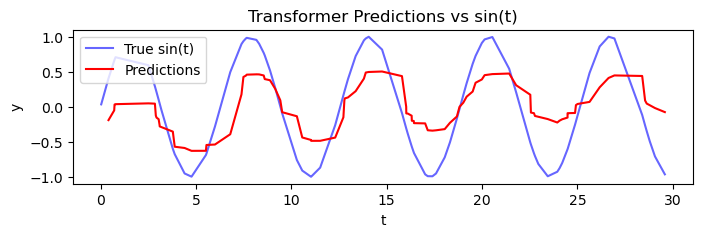

In [112]:
# Example usage - within initial range [0, 30]
# (GOOD)
t_test = np.sort(np.random.choice(100000000, size =100, replace = False))/100000000*30
t_axis, preds, true_y = generate_predictions(model, t_test, window_size=1)
plt.figure(figsize=(8,2))
plt.plot(t_test, true_y, label="True sin(t)", color="blue", alpha=0.6)
plt.plot(t_axis, preds, label="Predictions", color="red")
plt.xlabel("t") ;  plt.ylabel("y");  plt.title("Transformer Predictions vs sin(t)")
plt.legend(); plt.show()

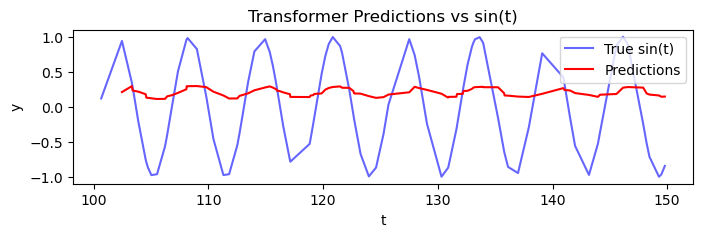

In [114]:
# Example usage - EXTRAPOLATION to t from the initial range [0,30] to [0,200]
# (BAD)  - the higher t, the more converging to 0 predictions are 
t_test = 100+np.sort(np.random.choice(100000000, size =100, replace = False))/100000000*50
t_axis, preds, true_y = generate_predictions(model, t_test, window_size=1)
plt.figure(figsize=(8,2))
plt.plot(t_test, true_y, label="True sin(t)", color="blue", alpha=0.6)
plt.plot(t_axis, preds, label="Predictions", color="red")
plt.xlabel("t") ;  plt.ylabel("y");  plt.title("Transformer Predictions vs sin(t)")
plt.legend(); plt.show()

### Test 1b

In [117]:
# Now we only supply ts, but for y replace with 0, and check the predictions 
# Those are similar to the above - this means that the model learnt y = sin(t) and 
# does not really relies on ys 

# results = IT DOES NEED PREVIOUS Ys and Ys(ts)

In [118]:
def generate_predictions_tonly(model, t_series, window_size=50, device="cpu"):
    """
    Args:
        model: trained TransformerTimeSeries
        t_series: 1D numpy array of times (sorted ascending)
        window_size: length of context window
    Returns:
        preds: numpy array of predictions aligned with t_series[window_size:]
    """
    model.eval()
    preds = []
    # true underlying function
    true_y =  np.sin(t_series) 
    with torch.no_grad():
        for i in range(len(t_series) - window_size):
            t_window = t_series[i:i+window_size]
            y_window = np.zeros(len(t_window))  # use true y for conditioning

            seq_input = np.stack([y_window, t_window], axis=1)  # (window, 2)
            seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)

            pred = model(seq_input).cpu().numpy().item()
            preds.append(pred)
    preds = np.array(preds)
    return t_series[window_size:], preds, np.sin(t_series)

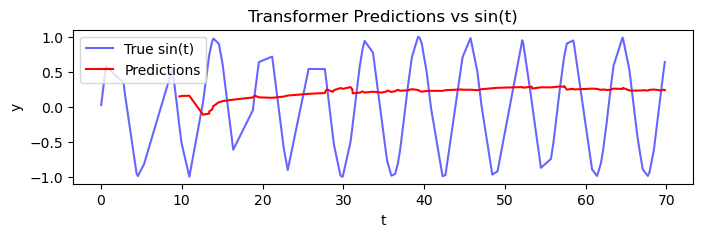

In [119]:
t_test = np.sort(np.random.choice(100000000, size =100, replace = False))/100000000*70
t_axis, preds, true_y = generate_predictions_tonly(model, t_test, window_size=10)

plt.figure(figsize=(8,2))
plt.plot(t_test, true_y, label="True sin(t)", color="blue", alpha=0.6)
plt.plot(t_axis, preds, label="Predictions", color="red")
plt.xlabel("t"); plt.ylabel("y"); plt.title("Transformer Predictions vs sin(t)"); plt.legend(); plt.show()

### Test 2

* **True forecasting:** given the history, predict for a given vector: **(t_window, y_window) -> y_future(t_future)**. 

* Plot past trajectory in green, model forecast y_future(t_future) in red, ground truth sin⁡(𝑡) in blue.

In [122]:
def forecast_future(model, t_window, y_window, t_future, device="cpu"):
    """
    Args:
        model: trained TransformerTimeSeries
        t_window: 1D numpy array, past times of length window_size
        y_window: 1D numpy array, past values of length window_size
        t_future: 1D numpy array, future times to predict
        device: "cpu" or "cuda"
    Returns:
        preds: numpy array of predictions for t_future
    """
    model.eval()
    preds = []
    with torch.no_grad():
        # start from the given window
        t_hist = list(t_window)
        y_hist = list(y_window)
        for t_next in t_future:
            # prepare input sequence (past window)
            seq_t = np.array(t_hist[-len(t_window):])
            seq_y = np.array(y_hist[-len(y_window):])
            seq_input = np.stack([seq_y, seq_t], axis=1)  # (window_size, 2)
            x = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
            # predict next y
            y_pred = model(x).cpu().item()
            preds.append(y_pred)
            # autoregressively append
            t_hist.append(t_next)
            y_hist.append(y_pred)
    return np.array(preds)

In [123]:
def plot_forecast(model, t_window, y_window, t_future, device="cpu"):
    preds = forecast_future(model, t_window, y_window, t_future, device=device)
    true_future = np.sin(t_future)
    plt.figure(figsize=(8,2))
    # past path
    plt.plot(t_window, y_window, color="green", label="Past y(t)")
    # predictions
    plt.plot(t_future, preds, color="red", label="Predicted y(t_future)")
    # ground truth
    plt.plot(t_future, true_future, color="blue", linestyle="--", label="True sin(t)")
    plt.title("Forecasting with TransformerTimeSeries")
    plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.show()


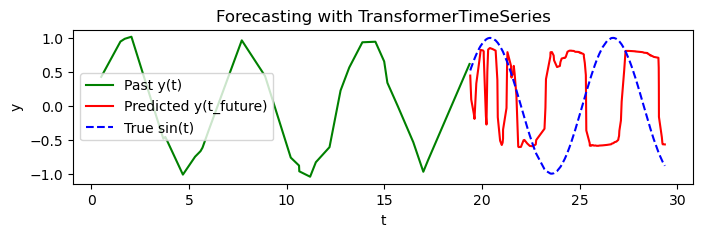

In [124]:
# Example usage
t_window = np.sort(np.random.choice(100000, size = window_size, replace = False))/100000*20
y_window = np.sin(t_window) + 0.1*np.random.randn(len(t_window))
t_future = np.max(t_window) + np.sort(np.random.choice(100000, size =150, replace = False))/100000*10
plot_forecast(model, t_window, y_window, t_future, device="cpu")


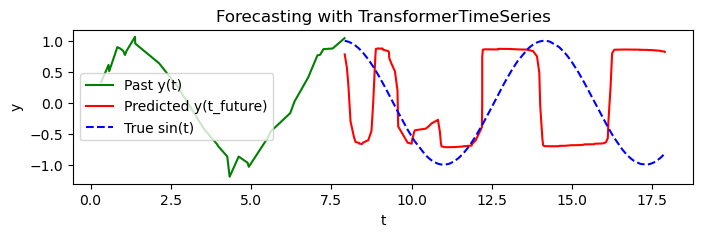

In [125]:
t_window = np.sort(np.random.choice(100000, size = window_size, replace = False))/100000*8
y_window = np.sin(t_window) + 0.1*np.random.randn(len(t_window))
t_future = np.max(t_window) + np.sort(np.random.choice(100000, size =150, replace = False))/100000*10
plot_forecast(model, t_window, y_window, t_future, device="cpu")

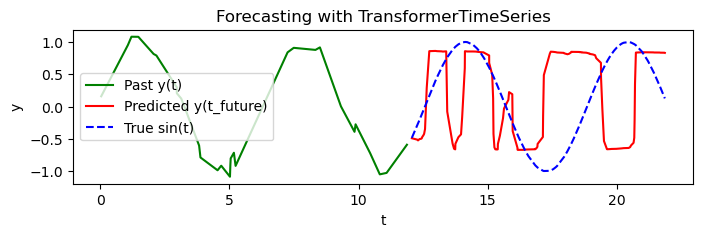

In [126]:
t_window = np.sort(np.random.choice(100000, size = window_size, replace = False))/100000*12
y_window = np.sin(t_window) + 0.1*np.random.randn(len(t_window))
t_future = np.max(t_window) + np.sort(np.random.choice(100000, size = 150, replace = False))/100000*10
plot_forecast(model, t_window, y_window, t_future, device="cpu")

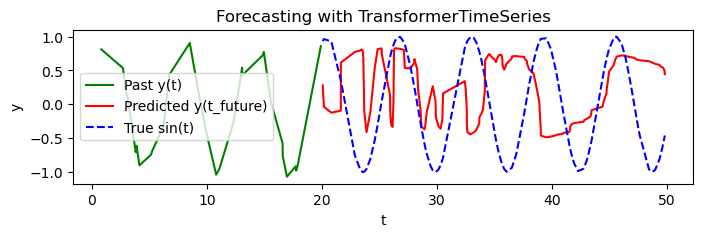

In [127]:
t_window = np.sort(np.random.choice(100000, size = window_size, replace = False))/100000*20
y_window = np.sin(t_window) + 0.1*np.random.randn(len(t_window))
t_future = np.max(t_window) + np.sort(np.random.choice(100000, size = 150, replace = False))/100000*30
plot_forecast(model, t_window, y_window, t_future, device="cpu")

In [128]:
# ** !! Adding MLP layers is essential ** Transformer itself is so so 